In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("LoanDataset - LoansDatasest.csv")

In [3]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


In [4]:
df.shape

(32586, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  object 
 3   home_ownership       32586 non-null  object 
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  object 
 6   loan_grade           32586 non-null  object 
 7   loan_amnt            32585 non-null  object 
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  object 
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 3.2+ MB


In [6]:
df.describe()

,customer_id,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length
count,32583.000000,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000
mean,16289.497806,27.732769,4.790161,11.011553,4.761738,5.804026
std,9405.919628,6.360528,4.142746,3.240440,2.471107,4.055078
min,1.000000,3.000000,0.000000,5.420000,1.000000,2.000000
25%,8144.500000,23.000000,2.000000,7.900000,3.000000,3.000000
50%,16288.000000,26.000000,4.000000,10.990000,4.000000,4.000000
75%,24433.500000,30.000000,7.000000,13.470000,7.000000,8.000000
max,32581.000000,144.000000,123.000000,23.220000,10.000000,30.000000


In [7]:
df.isnull().sum()

customer_id                3
customer_age               0
customer_income            0
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        4
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(6)

In [9]:
df = df.drop_duplicates()

## Data Cleaning

In [10]:
#Making all column names uniform
df.columns = df.columns.str.lower()

In [11]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


In [12]:
df['current_loan_status'].value_counts(normalize = True)

current_loan_status
NO DEFAULT    0.790152
DEFAULT       0.209848
Name: proportion, dtype: float64

In [13]:
#Removing '£' and ',' from loan_amnt
df['loan_amnt'] = (
    df['loan_amnt']
    .str.replace('£', '', regex=False)
    .str.replace(',', '', regex=False)    
)


In [14]:
df['loan_amnt'] = pd.to_numeric(df['loan_amnt'], errors = 'coerce')
df['customer_income'] = pd.to_numeric(df['customer_income'], errors = 'coerce')
df = df.drop(columns = ['customer_id'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32580 entries, 0 to 32585
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_age         32580 non-null  int64  
 1   customer_income      32576 non-null  float64
 2   home_ownership       32580 non-null  object 
 3   employment_duration  31685 non-null  float64
 4   loan_intent          32580 non-null  object 
 5   loan_grade           32580 non-null  object 
 6   loan_amnt            32579 non-null  float64
 7   loan_int_rate        29464 non-null  float64
 8   term_years           32580 non-null  int64  
 9   historical_default   11844 non-null  object 
 10  cred_hist_length     32580 non-null  int64  
 11  current_loan_status  32576 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 3.2+ MB


In [16]:
df.head()

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,current_loan_status
0,22,59000.0,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT
1,21,9600.0,OWN,5.0,EDUCATION,A,1000.0,11.14,1,NaN,2,NO DEFAULT
2,25,9600.0,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT
3,23,65500.0,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT
4,24,54400.0,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT


In [17]:
df.isnull().sum()

customer_age               0
customer_income            4
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20736
cred_hist_length           0
current_loan_status        4
dtype: int64

In [18]:
#The median is used instead of the mean because it is not thrown off by extreme values like a few unusually large salaries or interest rates.
df['employment_duration'] = df['employment_duration'].fillna(df['employment_duration'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

#The missing values are very few compared to the overall data. Hence, we drop the missing values.
df = df.dropna(subset=['customer_income'])
df = df.dropna(subset=['loan_amnt'])
df = df.dropna(subset=['current_loan_status'])

#The missing values are considerable and will definetly effect the data. Hence, we made a safe choice and fill the missing values with 'No history'
df['historical_default'] = df['historical_default'].fillna('Unknown')
df.head()

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,current_loan_status
0,22,59000.0,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT
1,21,9600.0,OWN,5.0,EDUCATION,A,1000.0,11.14,1,Unknown,2,NO DEFAULT
2,25,9600.0,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT
3,23,65500.0,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT
4,24,54400.0,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32571 entries, 0 to 32585
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_age         32571 non-null  int64  
 1   customer_income      32571 non-null  float64
 2   home_ownership       32571 non-null  object 
 3   employment_duration  32571 non-null  float64
 4   loan_intent          32571 non-null  object 
 5   loan_grade           32571 non-null  object 
 6   loan_amnt            32571 non-null  float64
 7   loan_int_rate        32571 non-null  float64
 8   term_years           32571 non-null  int64  
 9   historical_default   32571 non-null  object 
 10  cred_hist_length     32571 non-null  int64  
 11  current_loan_status  32571 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 3.2+ MB


## Feature Engineering

In [20]:
# Loan to income ratio
df['loan_to_income'] = df['loan_amnt'] / df['customer_income']

In [21]:
# Income bands show the bands of income of customers (i.e. Low, Medium or High)
df['income_band'] = pd.qcut(
    df['customer_income'],
    q=3,
    labels=['Low','Medium','High']
)
df

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,current_loan_status,loan_to_income,income_band
0,22,59000.0,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT,0.593220,Medium
1,21,9600.0,OWN,5.0,EDUCATION,A,1000.0,11.14,1,Unknown,2,NO DEFAULT,0.104167,Low
2,25,9600.0,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT,0.572917,Low
3,23,65500.0,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT,0.534351,Medium
4,24,54400.0,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT,0.643382,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32581,57,53000.0,MORTGAGE,1.0,PERSONAL,C,5800.0,13.16,7,Unknown,30,NO DEFAULT,0.109434,Medium
32582,54,120000.0,MORTGAGE,4.0,PERSONAL,A,17625.0,7.49,4,Unknown,19,NO DEFAULT,0.146875,High
32583,65,76000.0,RENT,3.0,HOMEIMPROVEMENT,B,35000.0,10.99,5,N,28,DEFAULT,0.460526,High
32584,56,150000.0,MORTGAGE,5.0,PERSONAL,B,15000.0,11.48,6,Unknown,26,NO DEFAULT,0.100000,High


In [22]:
# Creating age-group
def age_group(age):
    if age >= 18 and age <= 25:
        return '18-25'
    elif age > 25 and age <= 35:
        return '26-35'
    elif age > 35 and age <= 45:
        return '36-45'
    else:
        return '45+'
df['age_group'] = df['customer_age'].apply(age_group)

In [23]:
df

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,current_loan_status,loan_to_income,income_band,age_group
0,22,59000.0,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT,0.593220,Medium,18-25
1,21,9600.0,OWN,5.0,EDUCATION,A,1000.0,11.14,1,Unknown,2,NO DEFAULT,0.104167,Low,18-25
2,25,9600.0,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT,0.572917,Low,18-25
3,23,65500.0,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT,0.534351,Medium,18-25
4,24,54400.0,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT,0.643382,Medium,18-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32581,57,53000.0,MORTGAGE,1.0,PERSONAL,C,5800.0,13.16,7,Unknown,30,NO DEFAULT,0.109434,Medium,45+
32582,54,120000.0,MORTGAGE,4.0,PERSONAL,A,17625.0,7.49,4,Unknown,19,NO DEFAULT,0.146875,High,45+
32583,65,76000.0,RENT,3.0,HOMEIMPROVEMENT,B,35000.0,10.99,5,N,28,DEFAULT,0.460526,High,45+
32584,56,150000.0,MORTGAGE,5.0,PERSONAL,B,15000.0,11.48,6,Unknown,26,NO DEFAULT,0.100000,High,45+


In [24]:
# Creating interest rate categories

df['interest_rate_category'] = pd.qcut(
    df['loan_int_rate'],
    q=3,
    labels = ['Low rate', 'Medium rate', 'High rate']
)
df

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,current_loan_status,loan_to_income,income_band,age_group,interest_rate_category
0,22,59000.0,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT,0.593220,Medium,18-25,High rate
1,21,9600.0,OWN,5.0,EDUCATION,A,1000.0,11.14,1,Unknown,2,NO DEFAULT,0.104167,Low,18-25,Medium rate
2,25,9600.0,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT,0.572917,Low,18-25,High rate
3,23,65500.0,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT,0.534351,Medium,18-25,High rate
4,24,54400.0,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT,0.643382,Medium,18-25,High rate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32581,57,53000.0,MORTGAGE,1.0,PERSONAL,C,5800.0,13.16,7,Unknown,30,NO DEFAULT,0.109434,Medium,45+,High rate
32582,54,120000.0,MORTGAGE,4.0,PERSONAL,A,17625.0,7.49,4,Unknown,19,NO DEFAULT,0.146875,High,45+,Low rate
32583,65,76000.0,RENT,3.0,HOMEIMPROVEMENT,B,35000.0,10.99,5,N,28,DEFAULT,0.460526,High,45+,Medium rate
32584,56,150000.0,MORTGAGE,5.0,PERSONAL,B,15000.0,11.48,6,Unknown,26,NO DEFAULT,0.100000,High,45+,Medium rate


In [25]:
df['income_per_year_of_employment'] = (
    df['customer_income'] /
    (df['employment_duration'] + 1)
)

# Exploratory Data Analysis (EDA)

The objective of this analysis is to understand the distribution of customer and loan characteristics and identify patterns associated with loan default.

In [26]:
df['current_loan_status'].value_counts()

current_loan_status
NO DEFAULT    25740
DEFAULT        6831
Name: count, dtype: int64

In [27]:
df['current_loan_status'].value_counts(normalize=True) * 100

current_loan_status
NO DEFAULT    79.027356
DEFAULT       20.972644
Name: proportion, dtype: float64

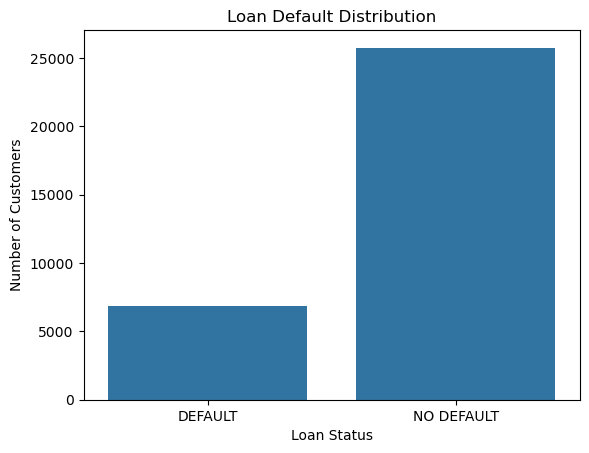

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='current_loan_status')
plt.title('Loan Default Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')
plt.show()

In [29]:
numeric_cols = [
    'customer_age',
    'customer_income',
    'employment_duration',
    'loan_amnt',
    'loan_int_rate',
    'term_years',
    'cred_hist_length',
    'loan_to_income'
]

In [30]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,32571.0,27.730742,6.358091,3.000000,23.000000,26.000000,30.000000,1.440000e+02
customer_income,32571.0,66065.752909,61981.306616,4000.000000,38500.000000,55000.000000,79200.000000,6.000000e+06
employment_duration,32571.0,4.767861,4.087648,0.000000,2.000000,4.000000,7.000000,1.230000e+02
loan_amnt,32571.0,9724.701422,21073.490596,500.000000,5000.000000,8000.000000,12200.000000,3.500000e+06
loan_int_rate,32571.0,11.009907,3.081733,5.420000,8.490000,10.990000,13.110000,2.322000e+01
term_years,32571.0,4.761229,2.470695,1.000000,3.000000,4.000000,7.000000,1.000000e+01
cred_hist_length,32571.0,5.802462,4.053371,2.000000,3.000000,4.000000,8.000000,3.000000e+01
loan_to_income,32571.0,0.172313,0.297747,0.000789,0.089681,0.148148,0.229167,4.964539e+01


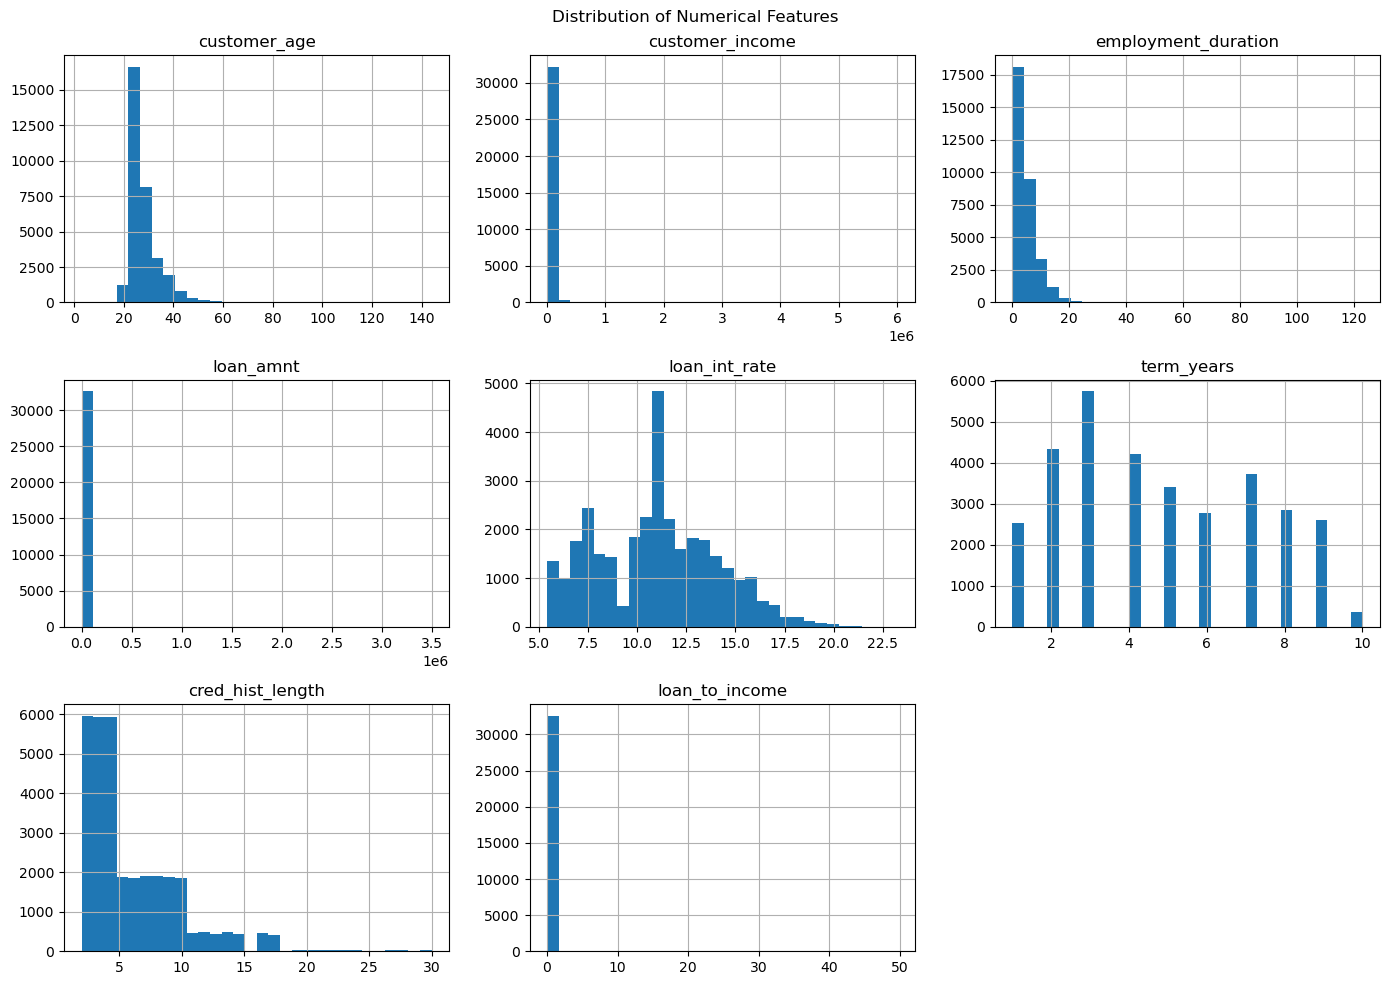

In [31]:
df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

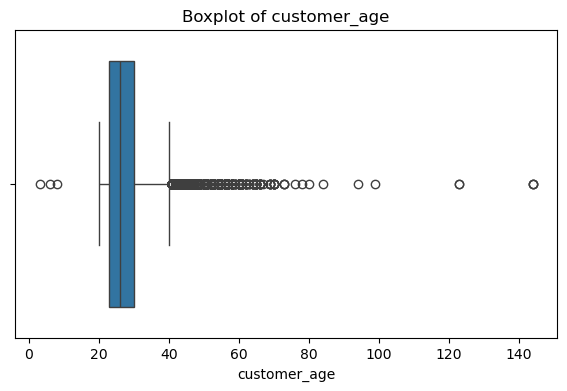

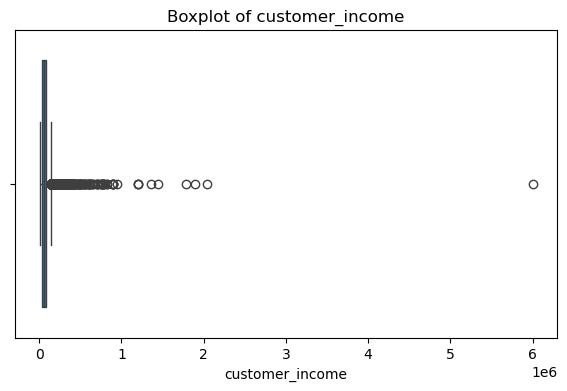

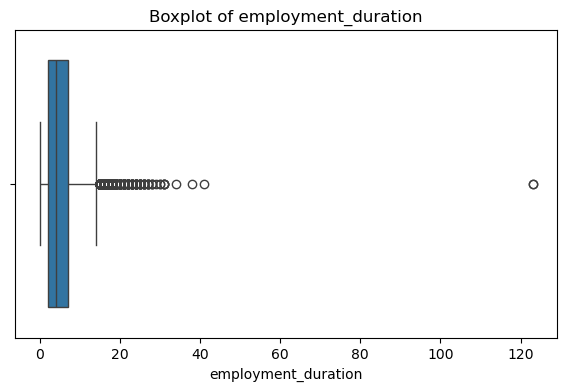

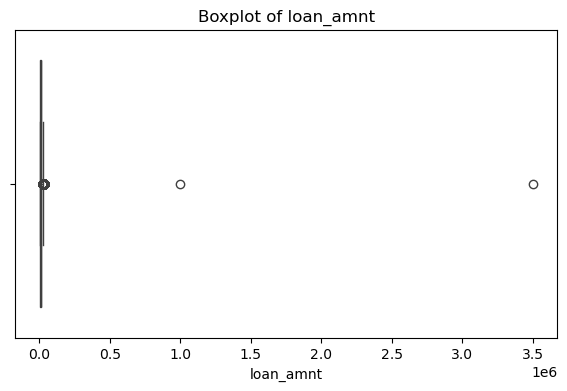

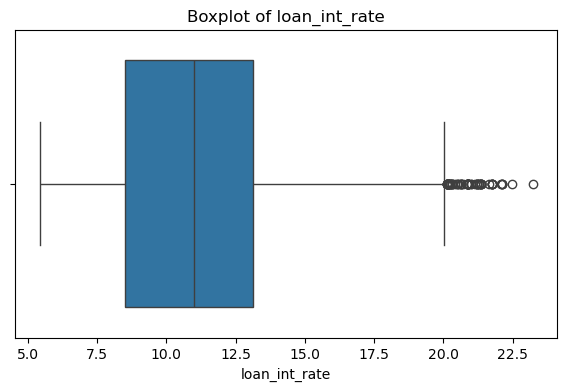

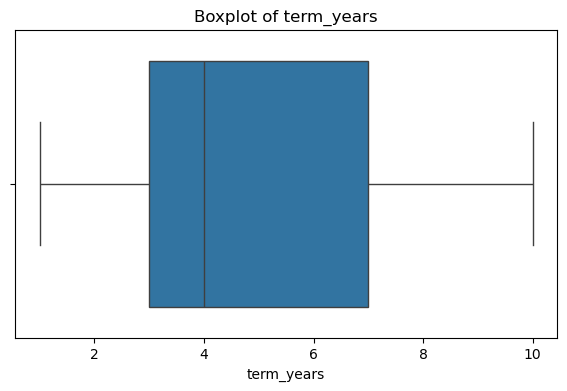

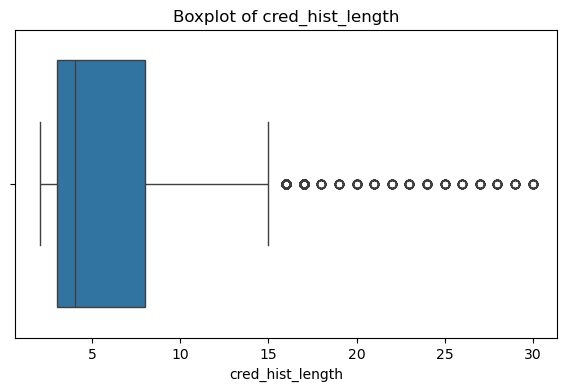

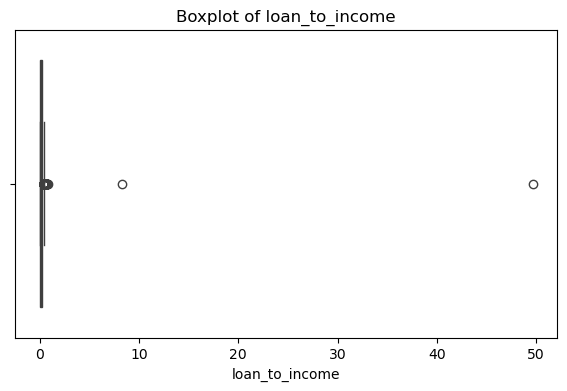

In [32]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [33]:
df[df['customer_age'] > 100][
    ['customer_age', 'customer_income', 'loan_amnt', 'employment_duration',
     'loan_int_rate', 'term_years', 'cred_hist_length', 'loan_to_income']
]

,customer_age,customer_income,loan_amnt,employment_duration,loan_int_rate,term_years,cred_hist_length,loan_to_income
81,144,250000.0,4800.0,4.0,13.57,4,3,0.019200
183,144,200000.0,6000.0,4.0,11.86,4,2,0.030000
577,123,80004.0,20400.0,2.0,10.25,9,3,0.254987
749,123,78000.0,20000.0,7.0,10.99,9,4,0.256410
32302,144,6000000.0,5000.0,12.0,12.73,4,25,0.000833


In [34]:
df[df['customer_income'] > 500000][
    ['customer_age', 'customer_income', 'loan_amnt', 'employment_duration',
     'loan_to_income']
]

,customer_age,customer_income,loan_amnt,employment_duration,loan_to_income
17837,32,1200000.0,12000.0,1.0,0.010000
17838,34,948000.0,2000.0,18.0,0.002110
17844,35,648000.0,10000.0,6.0,0.015432
17850,30,504000.0,3000.0,4.0,0.005952
18639,31,636000.0,17500.0,2.0,0.027516
18921,35,510000.0,1800.0,1.0,0.003529
21466,33,612000.0,5950.0,3.0,0.009722
21962,34,564000.0,6000.0,2.0,0.010638
23433,31,552000.0,8000.0,0.0,0.014493
23435,30,648000.0,8000.0,4.0,0.012346


In [35]:
df[df['loan_amnt'] > 100000][
    ['customer_age', 'customer_income', 'loan_amnt', 'employment_duration',
     'loan_to_income']
]

,customer_age,customer_income,loan_amnt,employment_duration,loan_to_income
322,25,120000.0,1000000.0,6.0,8.333333
17839,29,70500.0,3500000.0,5.0,49.645390


In [36]:
df[df['employment_duration'] > 50][
    ['customer_age', 'customer_income', 'loan_amnt', 'employment_duration']
]

,customer_age,customer_income,loan_amnt,employment_duration
0,22,59000.0,35000.0,123.0
210,21,192000.0,20000.0,123.0


In [37]:
df[df['loan_to_income'] > 1][
    ['customer_age', 'customer_income', 'loan_amnt', 'loan_to_income']
]

,customer_age,customer_income,loan_amnt,loan_to_income
322,25,120000.0,1000000.0,8.333333
17839,29,70500.0,3500000.0,49.645390


In [38]:
df.loc[df['customer_age'] > 100, 'customer_age'] = np.nan

In [39]:
df.loc[df['employment_duration'] > 50, 'employment_duration'] = np.nan

In [40]:
df[['customer_age', 'employment_duration']].isnull().sum()

customer_age           5
employment_duration    2
dtype: int64

In [41]:
df['customer_age'] = df['customer_age'].fillna(
    df['customer_age'].median()
)

df['employment_duration'] = df['employment_duration'].fillna(
    df['employment_duration'].median()
)

In [42]:
df[['customer_age', 'employment_duration']].describe()

,customer_age,employment_duration
count,32571.000000,32571.000000
mean,27.713917,4.760554
std,6.214738,3.981264
min,3.000000,0.000000
25%,23.000000,2.000000
50%,26.000000,4.000000
75%,30.000000,7.000000
max,99.000000,41.000000


In [43]:
df[['customer_income', 'loan_amnt']].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

,customer_income,loan_amnt
0.900,110004.0,19000.0
0.950,138000.0,24000.0
0.990,225000.0,29800.0
0.995,300000.0,35000.0
0.999,648000.0,35000.0


In [44]:
df[['customer_income', 'loan_amnt']].sort_values(
    by='customer_income',
    ascending=False
).head(20)

,customer_income,loan_amnt
32302,6000000.0,5000.0
30053,2039784.0,8450.0
32551,1900000.0,1500.0
32502,1782000.0,12025.0
31929,1440000.0,6400.0
31927,1362000.0,6600.0
17837,1200000.0,12000.0
29123,1200000.0,10000.0
29124,1200000.0,10000.0
17838,948000.0,2000.0


In [45]:
df[['customer_income', 'loan_amnt']].sort_values(
    by='loan_amnt',
    ascending=False
).head(20)

,customer_income,loan_amnt
17839,70500.0,3500000.0
322,120000.0,1000000.0
26448,102000.0,35000.0
26594,107000.0,35000.0
29138,133000.0,35000.0
29139,408000.0,35000.0
11335,73440.0,35000.0
15176,96050.0,35000.0
25708,78000.0,35000.0
11256,72400.0,35000.0


In [46]:
df['loan_amnt'].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1])

0.900      19000.0
0.950      24000.0
0.990      29800.0
0.995      35000.0
0.999      35000.0
1.000    3500000.0
Name: loan_amnt, dtype: float64

In [47]:
df['customer_income'].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1])

0.900     110004.0
0.950     138000.0
0.990     225000.0
0.995     300000.0
0.999     648000.0
1.000    6000000.0
Name: customer_income, dtype: float64

In [48]:
df[df['loan_amnt'] > 100000][
    ['customer_age', 'customer_income', 'loan_amnt',
     'loan_int_rate', 'loan_grade', 'current_loan_status']
]

,customer_age,customer_income,loan_amnt,loan_int_rate,loan_grade,current_loan_status
322,25.0,120000.0,1000000.0,10.74,A,DEFAULT
17839,29.0,70500.0,3500000.0,8.90,A,NO DEFAULT


In [49]:
df = df[df['loan_amnt'] <= 35000].copy()

In [50]:
df.loc[df['customer_age'] > 100, 'customer_age'] = np.nan

In [51]:
df.loc[df['employment_duration'] > 50, 'employment_duration'] = np.nan

In [52]:
df['customer_age'] = df['customer_age'].fillna(
    df['customer_age'].median()
)

df['employment_duration'] = df['employment_duration'].fillna(
    df['employment_duration'].median()
)

In [53]:
df['loan_to_income'] = (
    df['loan_amnt'] / df['customer_income']
)

In [54]:
df['loan_to_income'].describe()

count    32569.000000
mean         0.170544
std          0.107039
min          0.000789
25%          0.089655
50%          0.148148
75%          0.229167
max          0.830000
Name: loan_to_income, dtype: float64

### Outlier and Data Quality Treatment

During the numerical analysis, several anomalous observations were identified.

- `customer_age` contained values of 123 and 144 years, which are not plausible customer ages. These values were treated as missing and replaced using the median.
- `employment_duration` contained values of 123 years, which were considered data-quality errors. These values were treated as missing and replaced using the median.
- `loan_amnt` contained two extreme observations of £1,000,000 and £3,500,000. The 99.9th percentile of the feature was £35,000, indicating that these observations were highly inconsistent with the rest of the dataset. The two records were removed rather than capped.
- Extremely high `customer_income` values were retained because high income is not inherently invalid and there was insufficient evidence to classify these observations as data errors.

In [55]:
df.shape

(32569, 17)

In [56]:
df[['customer_age',
    'customer_income',
    'employment_duration',
    'loan_amnt',
    'loan_to_income']].describe()

,customer_age,customer_income,employment_duration,loan_amnt,loan_to_income
count,32569.000000,3.256900e+04,32569.000000,32569.000000,32569.000000
mean,27.713961,6.606396e+04,4.760508,9587.130400,0.170544
std,6.214907,6.198248e+04,3.981380,6319.876909,0.107039
min,3.000000,4.000000e+03,0.000000,500.000000,0.000789
25%,23.000000,3.850000e+04,2.000000,5000.000000,0.089655
50%,26.000000,5.500000e+04,4.000000,8000.000000,0.148148
75%,30.000000,7.920000e+04,7.000000,12200.000000,0.229167
max,99.000000,6.000000e+06,41.000000,35000.000000,0.830000


In [57]:
categorical_cols = [
    'home_ownership',
    'loan_intent',
    'loan_grade',
    'historical_default'
]

In [58]:
df['home_ownership'].value_counts()

home_ownership
RENT        16436
MORTGAGE    13443
OWN          2583
OTHER         107
Name: count, dtype: int64

In [59]:
pd.crosstab(
    df['home_ownership'],
    df['current_loan_status'],
    normalize='index'
) * 100

current_loan_status,DEFAULT,NO DEFAULT
home_ownership,,
MORTGAGE,11.574797,88.425203
OTHER,30.841121,69.158879
OWN,6.078204,93.921796
RENT,30.932100,69.067900


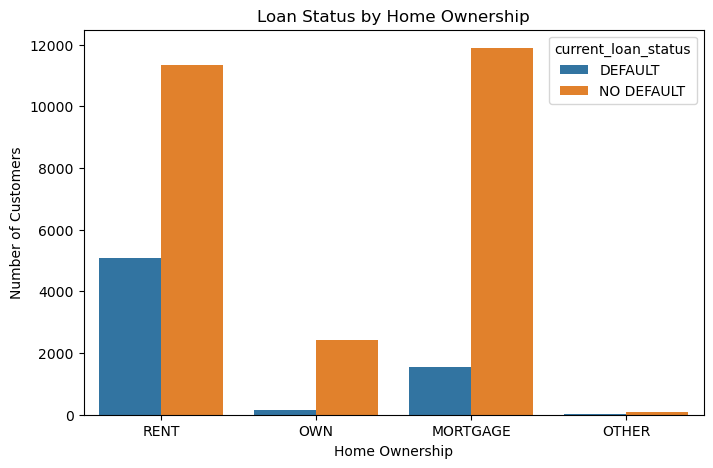

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='home_ownership',
    hue='current_loan_status'
)

plt.title('Loan Status by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Number of Customers')
plt.show()

In [61]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            6452
MEDICAL              6070
VENTURE              5717
PERSONAL             5518
DEBTCONSOLIDATION    5207
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [62]:
pd.crosstab(
    df['loan_intent'],
    df['current_loan_status'],
    normalize='index'
) * 100

current_loan_status,DEFAULT,NO DEFAULT
loan_intent,,
DEBTCONSOLIDATION,30.305358,69.694642
EDUCATION,15.902046,84.097954
HOMEIMPROVEMENT,24.466019,75.533981
MEDICAL,25.057661,74.942339
PERSONAL,18.503081,81.496919
VENTURE,14.028337,85.971663


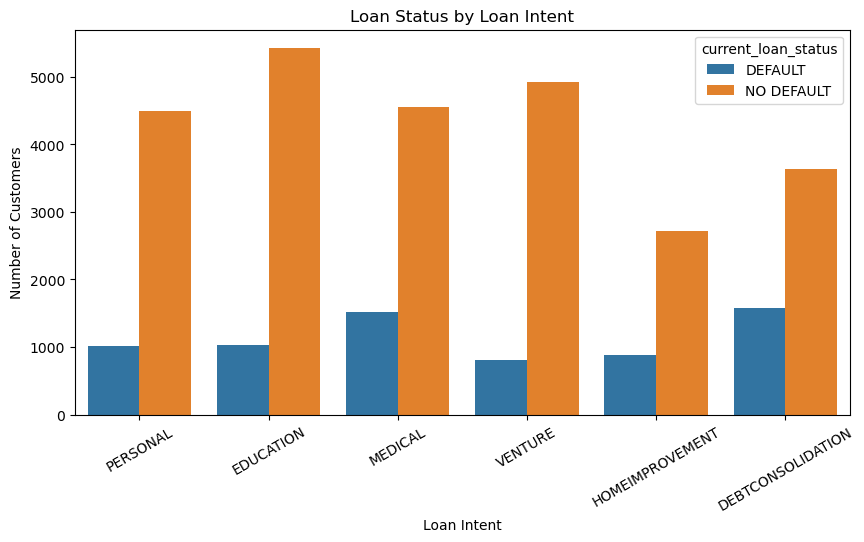

In [63]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='loan_intent',
    hue='current_loan_status'
)

plt.title('Loan Status by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

### Finding: Loan Intent and Default

Loan intent shows differences in observed default rates across categories. Debt consolidation had the highest default rate (30.31%), followed by medical (25.06%) and home improvement loans (24.47%). Venture loans had the lowest default rate (14.03%). These results indicate an association between loan purpose and default status in the dataset, but do not establish a causal relationship.

In [64]:
df['loan_grade'].value_counts()

loan_grade
A    15649
B     9062
C     4925
D     2628
E      305
Name: count, dtype: int64

In [65]:
pd.crosstab(
    df['loan_grade'],
    df['current_loan_status'],
    normalize='index'
) * 100

current_loan_status,DEFAULT,NO DEFAULT
loan_grade,,
A,9.962298,90.037702
B,19.300375,80.699625
C,35.756345,64.243655
D,58.599696,41.400304
E,72.459016,27.540984


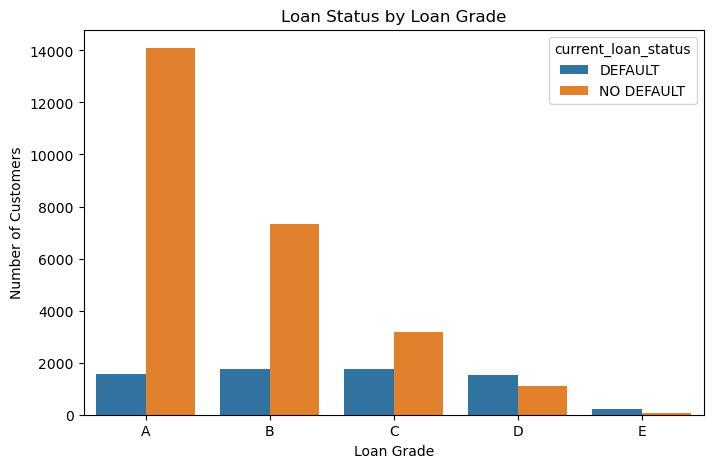

In [66]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='loan_grade',
    hue='current_loan_status',
    order=sorted(df['loan_grade'].dropna().unique())
)

plt.title('Loan Status by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Number of Customers')
plt.show()

### Finding: Loan Grade and Default

Loan grade shows a strong relationship with loan default in the dataset. The observed default rate increases consistently from 9.96% for Grade A loans to 72.46% for Grade E loans. Grade D and E loans have substantially higher default rates than Grades A–C, suggesting that loan grade is an important predictor of default risk in this dataset.

In [67]:
df['historical_default'].value_counts()

historical_default
Unknown    20735
Y           6126
N           5708
Name: count, dtype: int64

In [68]:
pd.crosstab(
    df['historical_default'],
    df['current_loan_status'],
    normalize='index'
) * 100

current_loan_status,DEFAULT,NO DEFAULT
historical_default,,
N,79.887877,20.112123
Unknown,0.000000,100.000000
Y,37.055175,62.944825


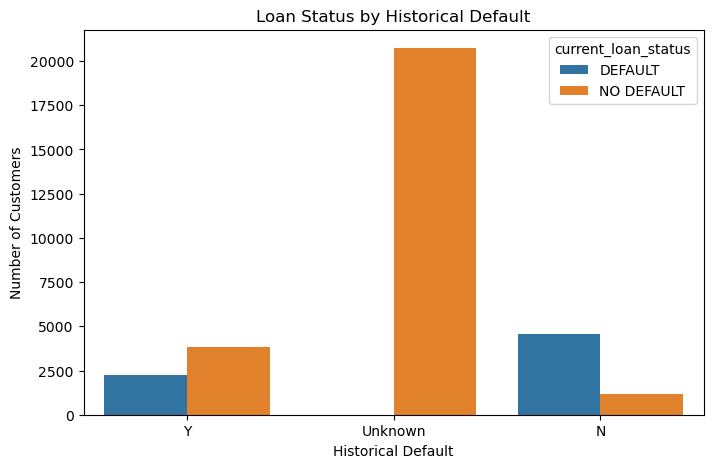

In [69]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='historical_default',
    hue='current_loan_status'
)

plt.title('Loan Status by Historical Default')
plt.xlabel('Historical Default')
plt.ylabel('Number of Customers')
plt.show()

In [70]:
df['historical_default'].value_counts()

historical_default
Unknown    20735
Y           6126
N           5708
Name: count, dtype: int64

In [71]:
df['historical_default'].isna().sum()

np.int64(0)

In [72]:
pd.crosstab(
    df['historical_default'],
    df['current_loan_status']
)

current_loan_status,DEFAULT,NO DEFAULT
historical_default,,
N,4560,1148
Unknown,0,20735
Y,2270,3856


In [73]:
df = df.drop(columns=['historical_default'])

### Finding: Historical Default and Data Leakage

The `historical_default` feature contained 20,735 observations labeled as `Unknown`. 
All 20,735 of these observations corresponded to the `NO DEFAULT` target class, resulting 
in a 0% observed default rate for the `Unknown` category.

This pattern indicates potential target leakage or target-dependent missingness. 
Including this feature in the predictive model could allow the model to indirectly 
identify the target rather than learn genuine relationships between applicant 
characteristics and default risk.

Therefore, `historical_default` was excluded from the predictive modeling stage.

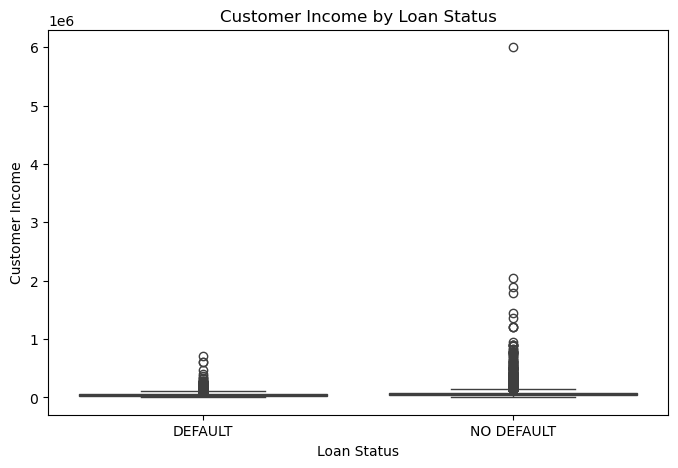

In [74]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='current_loan_status',
    y='customer_income'
)

plt.title('Customer Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Customer Income')
plt.show()

In [75]:
df.groupby('current_loan_status')['customer_income'].median()

current_loan_status
DEFAULT       42000.0
NO DEFAULT    60000.0
Name: customer_income, dtype: float64

### Finding: Customer Income and Default

The median annual income of customers who defaulted was 42,000, compared with 60,000 for customers who did not default. This suggests an association between lower customer income and higher observed default risk in the dataset.

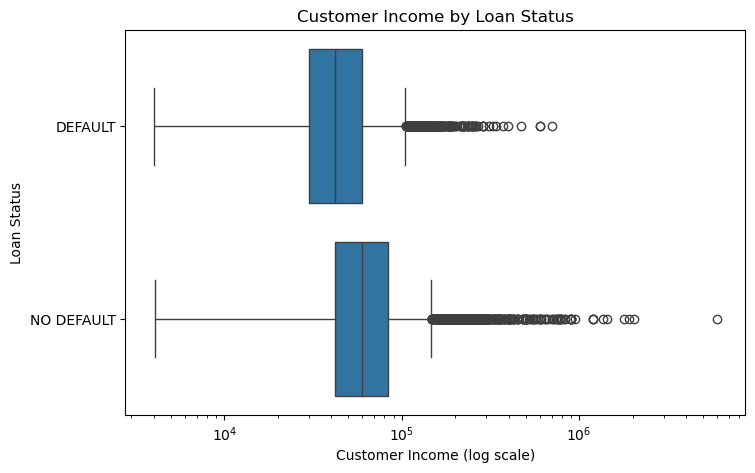

In [76]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='customer_income',
    y='current_loan_status'
)

plt.xscale('log')

plt.title('Customer Income by Loan Status')
plt.xlabel('Customer Income (log scale)')
plt.ylabel('Loan Status')

plt.show()

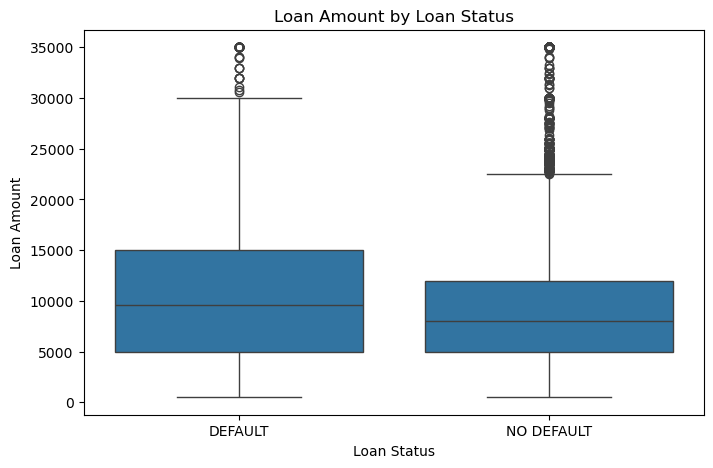

In [77]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='current_loan_status',
    y='loan_amnt'
)

plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')

plt.show()

In [78]:
df.groupby('current_loan_status')['loan_amnt'].median()

current_loan_status
DEFAULT       9600.0
NO DEFAULT    8000.0
Name: loan_amnt, dtype: float64

### Finding: Loan Amount and Default

Customers who defaulted had a median loan amount of £9,500, compared with £8,000 for customers who did not default. Although defaulted customers had a slightly higher median loan amount, the distributions overlap substantially, suggesting that loan amount alone may have limited ability to distinguish between default and non-default customers.

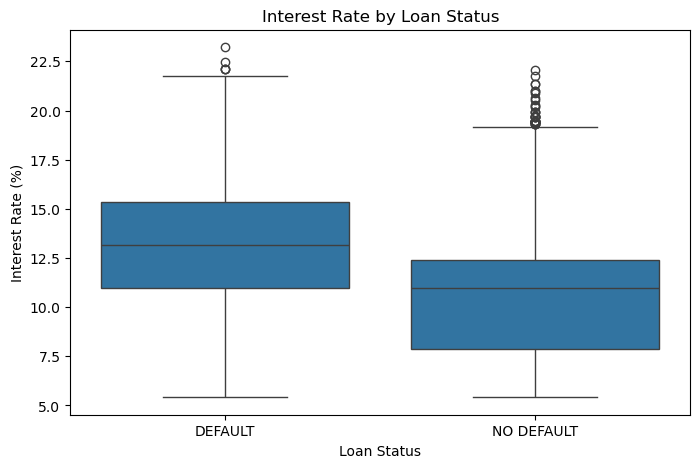

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='current_loan_status',
    y='loan_int_rate'
)

plt.title('Interest Rate by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Interest Rate (%)')

plt.show()

In [80]:
df.groupby('current_loan_status')['loan_int_rate'].median()

current_loan_status
DEFAULT       13.16
NO DEFAULT    10.99
Name: loan_int_rate, dtype: float64

### Finding: Interest Rate and Default

Customers who defaulted had a higher median interest rate (13.16%) than customers who did not default (10.99%). The distributions also show a general shift toward higher interest rates among defaulted customers, indicating an association between interest rate and default status in the dataset.

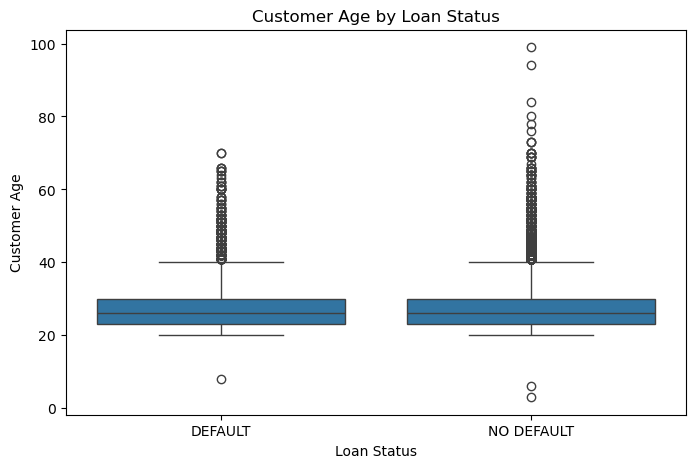

In [81]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='current_loan_status',
    y='customer_age'
)

plt.title('Customer Age by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Customer Age')

plt.show()

In [82]:
df.groupby('current_loan_status')['customer_age'].median()

current_loan_status
DEFAULT       26.0
NO DEFAULT    26.0
Name: customer_age, dtype: float64

### Finding: Customer Age and Default

The median customer age was 26 years for both defaulted and non-defaulted customers. The two distributions show substantial overlap, suggesting that customer age alone does not strongly differentiate default and non-default customers in this dataset.

In [83]:
df[df['customer_age'] < 18][
    ['customer_age', 'customer_income', 'loan_amnt', 'current_loan_status']
]

,customer_age,customer_income,loan_amnt,current_loan_status
29396,6.0,25000.0,11500.0,NO DEFAULT
29397,8.0,47000.0,16500.0,DEFAULT
29398,3.0,25000.0,10000.0,NO DEFAULT


In [84]:
df.loc[
    (df['customer_age'] < 18) | (df['customer_age'] > 100),
    'customer_age'
] = np.nan

In [85]:
df['customer_age'] = df['customer_age'].fillna(
    df['customer_age'].median()
)

### Invalid Customer Ages

The `customer_age` variable contained five implausible observations:
three customers had ages below 18 (3, 6, and 8 years), while two had ages
above 100 (123 and 144 years). These values were treated as data-quality
errors and replaced with missing values. The resulting missing values were
imputed using the median customer age.

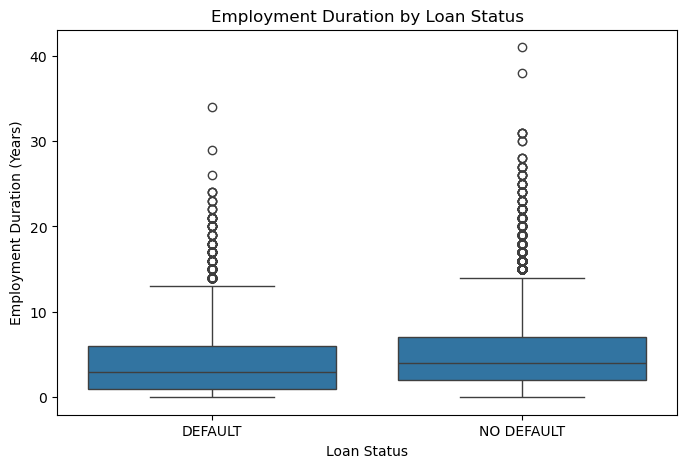

In [86]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='current_loan_status',
    y='employment_duration'
)

plt.title('Employment Duration by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Employment Duration (Years)')

plt.show()

In [87]:
df.groupby('current_loan_status')['employment_duration'].median()

current_loan_status
DEFAULT       3.0
NO DEFAULT    4.0
Name: employment_duration, dtype: float64

### Finding: Employment Duration and Default

Customers who defaulted had a median employment duration of 3 years, compared with 4 years for customers who did not default. The distributions show substantial overlap, suggesting that employment duration has some association with default status but may not be a strong standalone discriminator.

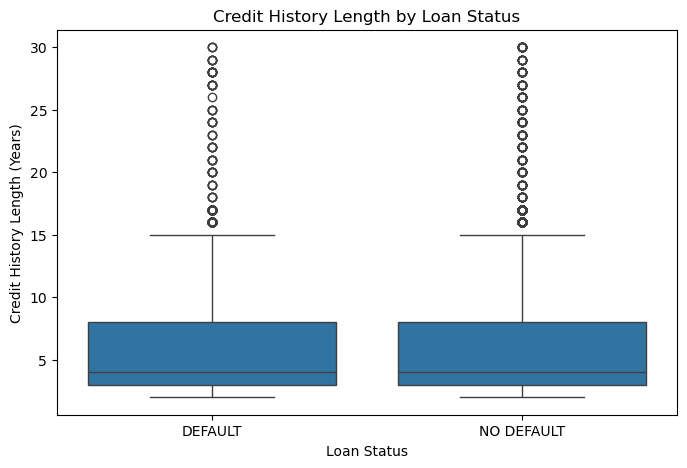

In [88]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='current_loan_status',
    y='cred_hist_length'
)

plt.title('Credit History Length by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Credit History Length (Years)')

plt.show()

In [89]:
df.groupby('current_loan_status')['cred_hist_length'].median()

current_loan_status
DEFAULT       4.0
NO DEFAULT    4.0
Name: cred_hist_length, dtype: float64

### Finding: Credit History Length and Default

The median credit history length was 4 years for both defaulted and non-defaulted customers. The distributions are highly similar and show substantial overlap, suggesting that credit history length alone does not strongly differentiate default and non-default customers in this dataset.

In [90]:
df['loan_to_income'].describe()

count    32569.000000
mean         0.170544
std          0.107039
min          0.000789
25%          0.089655
50%          0.148148
75%          0.229167
max          0.830000
Name: loan_to_income, dtype: float64

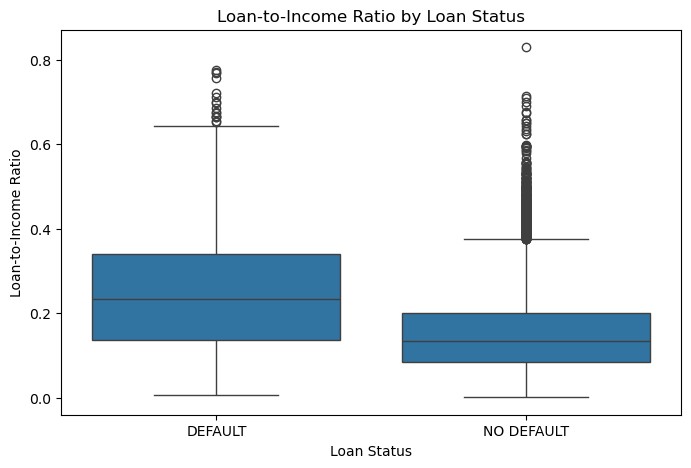

In [91]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='current_loan_status',
    y='loan_to_income'
)

plt.title('Loan-to-Income Ratio by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan-to-Income Ratio')

plt.show()

In [92]:
df.groupby('current_loan_status')['loan_to_income'].median()

current_loan_status
DEFAULT       0.233604
NO DEFAULT    0.134192
Name: loan_to_income, dtype: float64

### Finding: Loan-to-Income Ratio and Default

The median loan-to-income ratio was 0.2336 for customers who defaulted,
compared with 0.1342 for customers who did not default. The distribution
for defaulted customers is also shifted toward higher ratios, suggesting
that a higher loan-to-income ratio is associated with greater observed
default risk in the dataset.

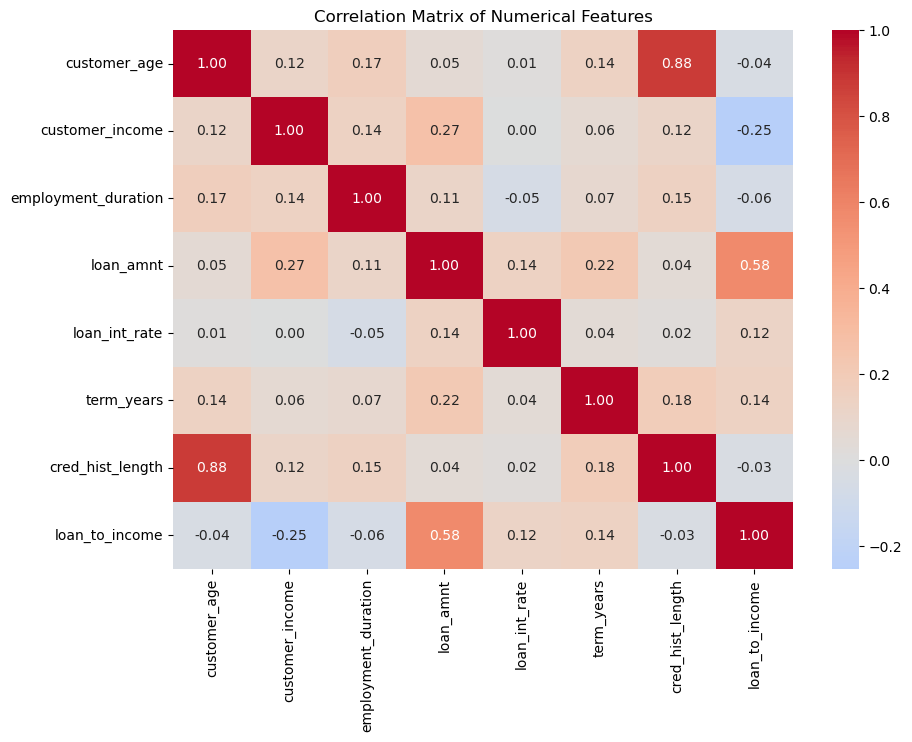

In [93]:
numeric_cols = [
    'customer_age',
    'customer_income',
    'employment_duration',
    'loan_amnt',
    'loan_int_rate',
    'term_years',
    'cred_hist_length',
    'loan_to_income'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Finding: Correlation Analysis

Most numerical features show relatively weak correlations with one another. The strongest relationship is between customer age and credit history length (r = 0.88), which is intuitively plausible because older customers generally have longer credit histories. This relationship should be considered when evaluating linear models for multicollinearity.

# Key EDA Findings

- Loan grade showed the strongest categorical relationship with default rate, increasing from 9.96% for Grade A to 72.46% for Grade E.
- Customers with RENT home ownership had a higher observed default rate (30.93%) than customers with a MORTGAGE (11.57%) or OWN (6.08%) status.
- Debt consolidation loans had the highest default rate among loan intents (30.31%), while venture loans had the lowest (14.03%).
- Defaulted customers had a lower median annual income (42,000) than non-defaulted customers (60,000).
- Defaulted customers had a slightly higher median loan amount (9,500) than non-defaulted customers (8,000).
- Defaulted customers had a higher median interest rate (13.16%) than non-defaulted customers (10.99%).
- Loan-to-income ratio was higher among defaulted customers, with median values of 0.2336 versus 0.1342 for non-defaulted customers.
- Customer age and credit history length showed substantial overlap between default groups.
- The `historical_default` feature contained an unusual missing-value pattern in which all 20,735 `Unknown` observations belonged to the `NO DEFAULT` class. This feature was therefore excluded from predictive modeling because of potential target leakage.

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32569 entries, 0 to 32585
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   customer_age                   32569 non-null  float64 
 1   customer_income                32569 non-null  float64 
 2   home_ownership                 32569 non-null  object  
 3   employment_duration            32569 non-null  float64 
 4   loan_intent                    32569 non-null  object  
 5   loan_grade                     32569 non-null  object  
 6   loan_amnt                      32569 non-null  float64 
 7   loan_int_rate                  32569 non-null  float64 
 8   term_years                     32569 non-null  int64   
 9   cred_hist_length               32569 non-null  int64   
 10  current_loan_status            32569 non-null  object  
 11  loan_to_income                 32569 non-null  float64 
 12  income_band                    32569 

In [95]:
df.head()

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,cred_hist_length,current_loan_status,loan_to_income,income_band,age_group,interest_rate_category,income_per_year_of_employment
0,22.0,59000.0,RENT,4.0,PERSONAL,C,35000.0,16.02,10,3,DEFAULT,0.593220,Medium,18-25,High rate,475.806452
1,21.0,9600.0,OWN,5.0,EDUCATION,A,1000.0,11.14,1,2,NO DEFAULT,0.104167,Low,18-25,Medium rate,1600.000000
2,25.0,9600.0,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,3,DEFAULT,0.572917,Low,18-25,High rate,4800.000000
3,23.0,65500.0,RENT,4.0,MEDICAL,B,35000.0,15.23,10,2,DEFAULT,0.534351,Medium,18-25,High rate,13100.000000
4,24.0,54400.0,RENT,8.0,MEDICAL,B,35000.0,14.27,10,4,DEFAULT,0.643382,Medium,18-25,High rate,6044.444444


In [96]:
df = df.drop(columns=['income_per_year_of_employment'])

In [97]:
X = df.drop(columns=['current_loan_status'])
y = df['current_loan_status']

In [98]:
X.shape, y.shape

((32569, 14), (32569,))

In [99]:
y = y.map({
    'NO DEFAULT': 0,
    'DEFAULT': 1
})

In [100]:
y.value_counts(normalize=True) * 100

current_loan_status
0    79.029138
1    20.970862
Name: proportion, dtype: float64

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['customer_age', 'customer_income', 'employment_duration', 'loan_amnt', 'loan_int_rate', 'term_years', 'cred_hist_length', 'loan_to_income']

Categorical features:
['home_ownership', 'loan_intent', 'loan_grade', 'income_band', 'age_group', 'interest_rate_category']


In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [104]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

In [106]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
y_pred = logistic_model.predict(X_test)

In [108]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [109]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7950568007368745
Precision: 0.5072735804786486
Recall: 0.7913616398243045
F1 Score: 0.6182442093222762
ROC-AUC: 0.8703253392126014


In [110]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.80      0.86      5148
           1       0.51      0.79      0.62      1366

    accuracy                           0.80      6514
   macro avg       0.72      0.79      0.74      6514
weighted avg       0.85      0.80      0.81      6514



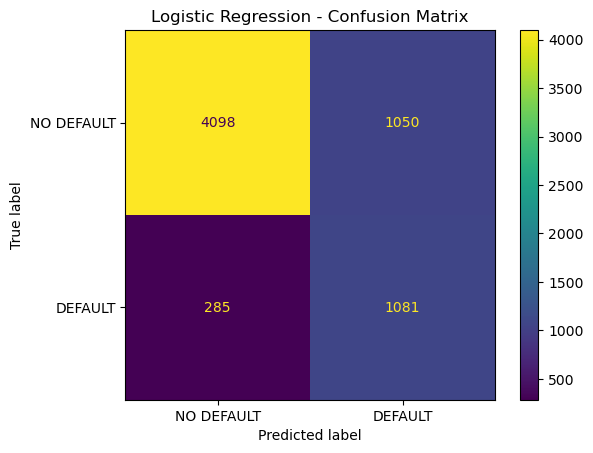

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['NO DEFAULT', 'DEFAULT']
)

plt.title('Logistic Regression - Confusion Matrix')
plt.show()

# Model Building

## 1. Logistic Regression - Baseline

## 2. Decision Tree

In [112]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
            max_depth=8
        ))
    ]
)

In [113]:
decision_tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [114]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [115]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Accuracy: 0.8962235185753761
Precision: 0.7720820189274448
Recall: 0.7166910688140556
F1 Score: 0.7433561123766135
ROC-AUC: 0.8908218631864312


In [116]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      5148
           1       0.77      0.72      0.74      1366

    accuracy                           0.90      6514
   macro avg       0.85      0.83      0.84      6514
weighted avg       0.89      0.90      0.89      6514



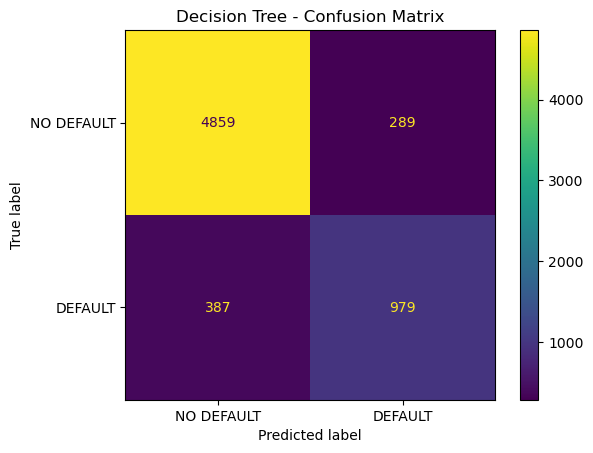

In [117]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=['NO DEFAULT', 'DEFAULT']
)

plt.title('Decision Tree - Confusion Matrix')
plt.show()

In [118]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [119]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [120]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [121]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9120356155971753
Precision: 0.8124507486209613
Recall: 0.7547584187408491
F1 Score: 0.7825426944971537
ROC-AUC: 0.9315539674251241


In [122]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5148
           1       0.81      0.75      0.78      1366

    accuracy                           0.91      6514
   macro avg       0.87      0.85      0.86      6514
weighted avg       0.91      0.91      0.91      6514



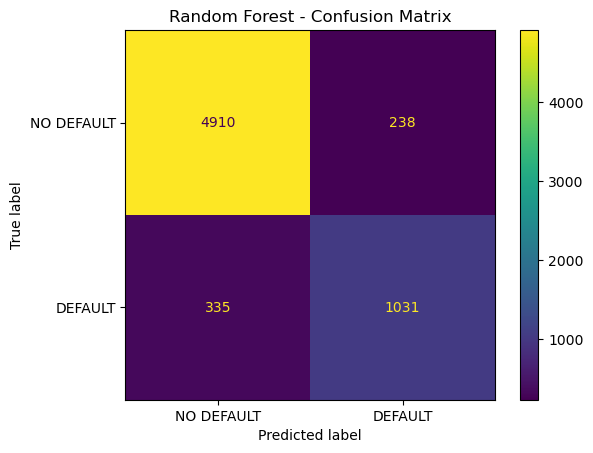

In [123]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['NO DEFAULT', 'DEFAULT']
)

plt.title('Random Forest - Confusion Matrix')
plt.show()

In [124]:
import xgboost
print(xgboost.__version__)

3.4.1


In [126]:
from xgboost import XGBClassifier

In [127]:
xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [128]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [129]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [130]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.935216456862143
Precision: 0.9495238095238095
Recall: 0.7298682284040996
F1 Score: 0.8253311258278145
ROC-AUC: 0.951025060834724


In [131]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5148
           1       0.95      0.73      0.83      1366

    accuracy                           0.94      6514
   macro avg       0.94      0.86      0.89      6514
weighted avg       0.94      0.94      0.93      6514



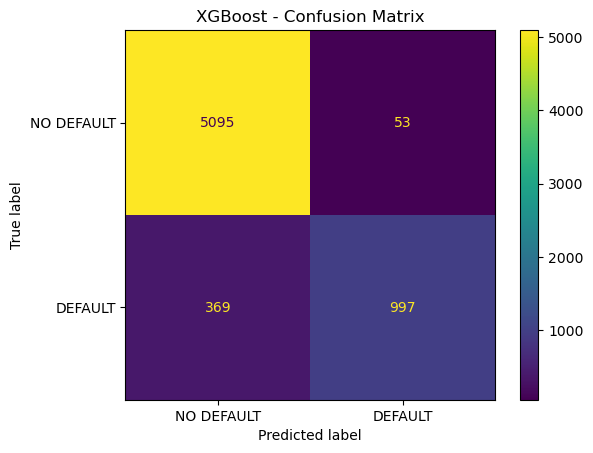

In [132]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=['NO DEFAULT', 'DEFAULT']
)

plt.title('XGBoost - Confusion Matrix')
plt.show()

In [133]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("F1 Score:", f1_score(y_test, y_pred_threshold))


Threshold: 0.3
Precision: 0.8482213438735178
Recall: 0.7855051244509517
F1 Score: 0.8156594450779171

Threshold: 0.4
Precision: 0.9110320284697508
Recall: 0.7496339677891655
F1 Score: 0.8224899598393575

Threshold: 0.5
Precision: 0.9495238095238095
Recall: 0.7298682284040996
F1 Score: 0.8253311258278145

Threshold: 0.6
Precision: 0.9726166328600405
Recall: 0.7020497803806734
F1 Score: 0.8154761904761905

Threshold: 0.7
Precision: 0.9798087141339001
Recall: 0.6749633967789166
F1 Score: 0.799306458604248


In [134]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [135]:
from sklearn.model_selection import RandomizedSearchCV

In [136]:
param_grid = {
    'classifier__n_estimators': [200, 300, 400, 500],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [138]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [139]:
random_search.fit(X_train_sub, y_train_sub)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [200, 300, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [140]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Best parameters:
{'classifier__subsample': 1.0, 'classifier__n_estimators': 500, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}

Best CV ROC-AUC:
0.9426425038355436


In [141]:
best_xgb = random_search.best_estimator_

In [142]:
best_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [143]:
y_val_prob = best_xgb.predict_proba(X_val)[:, 1]

In [144]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_val, y_val_pred))
    print("Recall:", recall_score(y_val, y_val_pred))
    print("F1 Score:", f1_score(y_val, y_val_pred))


Threshold: 0.3
Precision: 0.9638318670576735
Recall: 0.9021043000914913
F1 Score: 0.9319470699432892

Threshold: 0.35
Precision: 0.9766260162601627
Recall: 0.879231473010064
F1 Score: 0.9253731343283582

Threshold: 0.4
Precision: 0.9831223628691983
Recall: 0.8526989935956084
F1 Score: 0.9132778049975502

Threshold: 0.45
Precision: 0.9870550161812298
Recall: 0.8371454711802379
F1 Score: 0.905940594059406

Threshold: 0.5
Precision: 0.9889867841409692
Recall: 0.8215919487648673
F1 Score: 0.8975512243878061

Threshold: 0.55
Precision: 0.990990990990991
Recall: 0.8051235132662397
F1 Score: 0.8884401817264008

Threshold: 0.6
Precision: 0.9930232558139535
Recall: 0.7813357731015553
F1 Score: 0.8745519713261649


In [145]:
best_xgb = random_search.best_estimator_

In [146]:
y_val_prob = best_xgb.predict_proba(X_val)[:, 1]

In [147]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_val, y_val_pred))
    print("Recall:", recall_score(y_val, y_val_pred))
    print("F1 Score:", f1_score(y_val, y_val_pred))


Threshold: 0.3
Precision: 0.9638318670576735
Recall: 0.9021043000914913
F1 Score: 0.9319470699432892

Threshold: 0.35
Precision: 0.9766260162601627
Recall: 0.879231473010064
F1 Score: 0.9253731343283582

Threshold: 0.4
Precision: 0.9831223628691983
Recall: 0.8526989935956084
F1 Score: 0.9132778049975502

Threshold: 0.45
Precision: 0.9870550161812298
Recall: 0.8371454711802379
F1 Score: 0.905940594059406

Threshold: 0.5
Precision: 0.9889867841409692
Recall: 0.8215919487648673
F1 Score: 0.8975512243878061

Threshold: 0.55
Precision: 0.990990990990991
Recall: 0.8051235132662397
F1 Score: 0.8884401817264008

Threshold: 0.6
Precision: 0.9930232558139535
Recall: 0.7813357731015553
F1 Score: 0.8745519713261649


### Threshold Selection

The classification threshold was selected using the validation set rather than
the final test set. A threshold of 0.30 provided the highest F1-score (93.19%)
and achieved 90.21% recall with 96.38% precision.

This threshold was selected to provide a strong balance between identifying
potential defaulters and minimizing false-positive classifications.

In [148]:
best_xgb = random_search.best_estimator_

best_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [149]:
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

In [150]:
final_threshold = 0.30

y_test_pred = (
    y_test_prob >= final_threshold
).astype(int)

In [151]:
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))

Accuracy: 0.9292293521645686
Precision: 0.8646253021756648
Recall: 0.7855051244509517
F1 Score: 0.823168392788646
ROC-AUC: 0.9534747321167525


In [152]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=['NO DEFAULT', 'DEFAULT']
    )
)

              precision    recall  f1-score   support

  NO DEFAULT       0.94      0.97      0.96      5148
     DEFAULT       0.86      0.79      0.82      1366

    accuracy                           0.93      6514
   macro avg       0.90      0.88      0.89      6514
weighted avg       0.93      0.93      0.93      6514



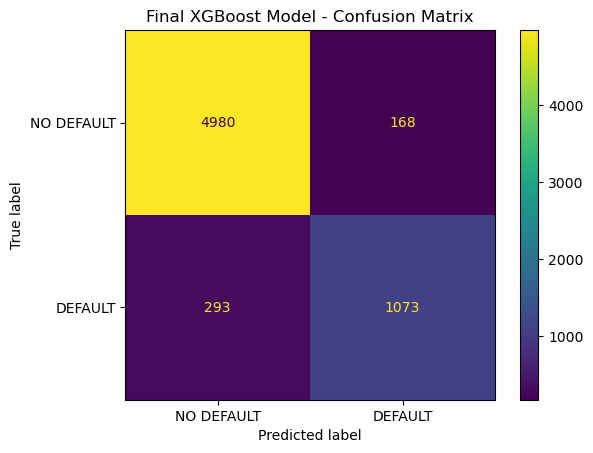

In [153]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=['NO DEFAULT', 'DEFAULT']
)

plt.title('Final XGBoost Model - Confusion Matrix')
plt.show()

## Final Model Performance

The tuned XGBoost model was evaluated on the previously untouched test set
using a classification threshold of 0.30, selected using the validation set.

The final model achieved:

- Accuracy: 92.92%
- Precision: 86.46%
- Recall: 78.55%
- F1-score: 82.32%
- ROC-AUC: 95.35%

The confusion matrix contained 1,073 true positives, 293 false negatives,
168 false positives, and 4,980 true negatives.

The model demonstrates strong discriminatory performance, with a ROC-AUC
of 0.9535. The selected threshold prioritizes detecting potential defaults
while maintaining relatively high precision.

In [154]:
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

importances = best_xgb.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(
    'importance',
    ascending=False
)

feature_importance.head(15)

,feature,importance
30,cat__interest_rate_category_High rate,0.174608
11,cat__home_ownership_RENT,0.090894
21,cat__loan_grade_D,0.060233
10,cat__home_ownership_OWN,0.052776
18,cat__loan_grade_A,0.044431
7,num__loan_to_income,0.041621
12,cat__loan_intent_DEBTCONSOLIDATION,0.040088
24,cat__income_band_Low,0.038169
8,cat__home_ownership_MORTGAGE,0.037588
19,cat__loan_grade_B,0.035027


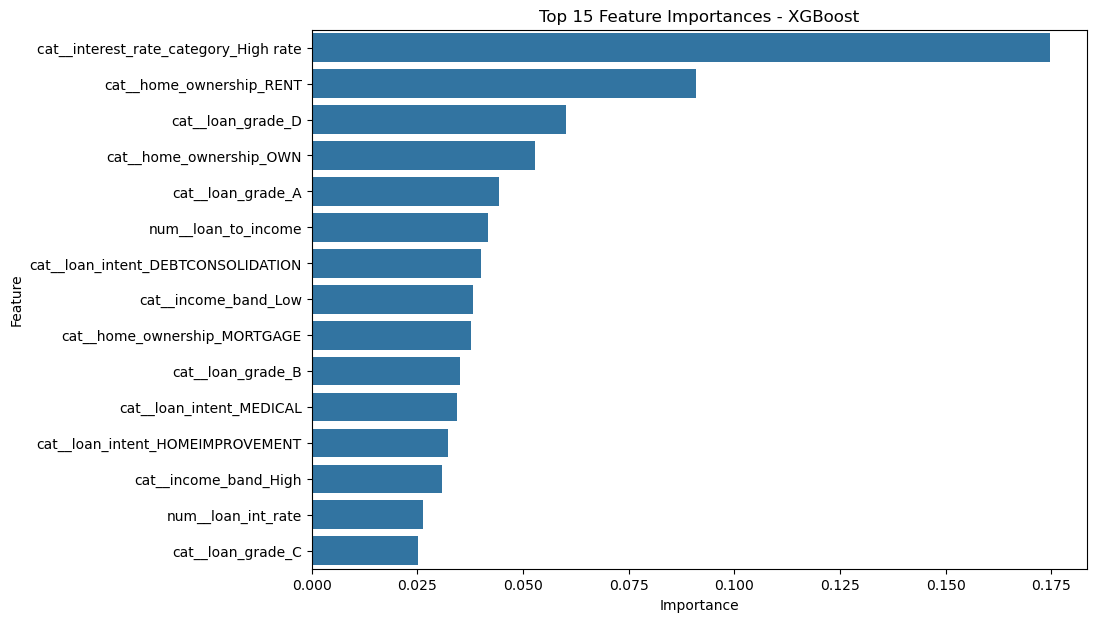

In [155]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x='importance',
    y='feature'
)

plt.title('Top 15 Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [156]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [157]:
import shap

In [158]:
X_test_transformed = best_xgb.named_steps[
    'preprocessor'
].transform(X_test)

In [159]:
feature_names = best_xgb.named_steps[
    'preprocessor'
].get_feature_names_out()

In [160]:
explainer = shap.TreeExplainer(
    best_xgb.named_steps['classifier']
)

In [161]:
shap_values = explainer.shap_values(
    X_test_transformed
)

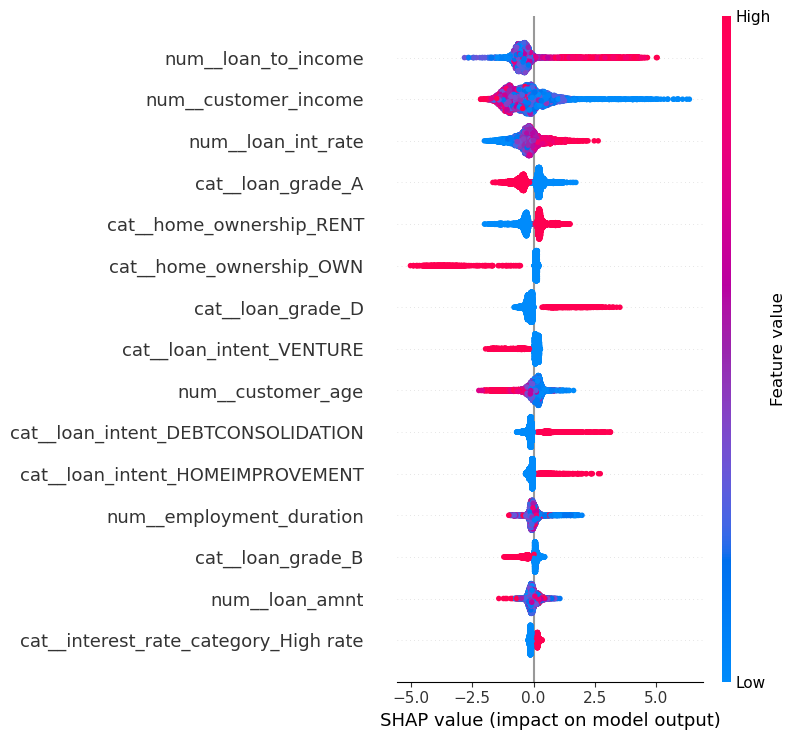

In [162]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

## SHAP Model Explainability

SHAP analysis was used to understand how individual features influence
the XGBoost model's predictions.

The strongest model driver was `loan_to_income`. Higher loan-to-income
values generally pushed predictions toward default, while lower values
tended to push predictions toward non-default.

Customer income showed the opposite pattern: higher income generally
reduced the model's predicted default risk, while lower income tended
to increase it.

Higher interest rates generally pushed predictions toward default.

Categorical variables also showed meaningful effects. The presence of
`loan_grade_A` and `home_ownership_OWN` generally pushed predictions
toward non-default, while `home_ownership_RENT` and `loan_grade_D`
generally pushed predictions toward default.

These model explanations are broadly consistent with the relationships
observed during exploratory data analysis.

In [163]:
import numpy as np
import pandas as pd

# Mean absolute SHAP value for each encoded feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
})

# Map encoded features back to their original features
def get_original_feature(feature):
    if feature.startswith('num__'):
        return feature.replace('num__', '')
    
    if feature.startswith('cat__'):
        feature = feature.replace('cat__', '')
        
        original_features = [
            'home_ownership',
            'loan_intent',
            'loan_grade',
            'income_band',
            'age_group',
            'interest_rate_category'
        ]
        
        for original in original_features:
            if feature.startswith(original + '_'):
                return original
    
    return feature

shap_importance['original_feature'] = (
    shap_importance['feature'].apply(get_original_feature)
)

grouped_shap = (
    shap_importance
    .groupby('original_feature')['mean_abs_shap']
    .sum()
    .sort_values(ascending=False)
)

grouped_shap

original_feature
loan_grade                1.038975
home_ownership            0.917277
loan_intent               0.910480
loan_to_income            0.755744
customer_income           0.727796
loan_int_rate             0.463261
customer_age              0.261118
income_band               0.170805
interest_rate_category    0.165581
employment_duration       0.159557
loan_amnt                 0.148076
cred_hist_length          0.134290
term_years                0.057970
age_group                 0.036445
Name: mean_abs_shap, dtype: float32

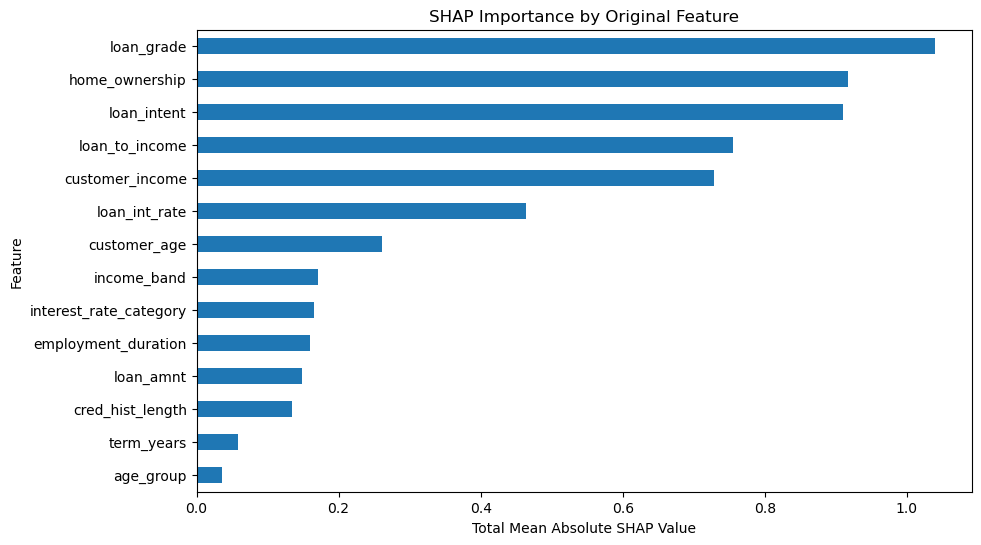

In [164]:
plt.figure(figsize=(10, 6))

grouped_shap.sort_values().plot(kind='barh')

plt.title('SHAP Importance by Original Feature')
plt.xlabel('Total Mean Absolute SHAP Value')
plt.ylabel('Feature')

plt.show()

# Business Recommendations

### 1. Strengthen Risk Assessment for High-Risk Loan Grades

Loan grade is the most influential feature in the model. The EDA also showed
substantially higher default rates for lower loan grades.

Lenders should apply stricter underwriting criteria and additional verification
for applicants assigned to higher-risk grades.

### 2. Incorporate Loan-to-Income Ratio

Loan-to-income ratio is one of the strongest numerical predictors of default.

Applicants with a high loan amount relative to their income should receive
additional affordability assessment before approval.

Possible actions include reducing the approved loan amount, requesting
additional documentation, or applying additional risk controls.

### 3. Consider Customer Income in Credit Assessment

Customer income is among the most important model features. Lower-income
customers showed higher predicted default risk.

Income should therefore be considered together with the requested loan amount
rather than evaluating income independently.

### 4. Risk-Based Interest Rate Assessment

Interest rate is an important predictor of default risk.

Higher interest rates were associated with higher predicted default risk in
the SHAP analysis. Lenders should monitor whether high-risk applicants are
being concentrated in higher-rate products and assess affordability carefully.

### 5. Use Loan Intent as a Risk Segmentation Variable

Loan intent is one of the strongest grouped features.

Different loan purposes showed different default rates during EDA. Lenders
could therefore use loan purpose as one component of risk segmentation and
apply additional review to higher-risk purposes.

### 6. Use Home Ownership as a Supporting Risk Signal

Home ownership was another highly influential feature.

Applicants renting their homes showed higher observed default rates than
customers who owned their homes. However, home ownership should be treated
as a supporting risk factor rather than an automatic rejection criterion.

### 7. Use the Model as a Decision-Support Tool

The model should support credit analysts rather than replace human review.

Customers identified as high-risk can be sent for additional assessment,
while lower-risk applications can potentially move through a faster
approval process.

# Challenges and Limitations

### 1. Class Imbalance

The dataset contains substantially more non-default observations than
default observations. Therefore, accuracy alone is not sufficient for
evaluating the model.

Precision, recall, F1-score and ROC-AUC were also considered.

### 2. Outliers

Several numerical variables contained extreme observations, particularly
customer income, loan amount, customer age and employment duration.

These observations required investigation before modeling.

### 3. Model Interpretability

XGBoost provides strong predictive performance but is less inherently
interpretable than logistic regression.

SHAP was therefore used to explain the contribution of individual features.

### 4. Threshold Trade-off

The classification threshold affects the balance between precision and recall.

A threshold of 0.30 was selected using validation data because it provided
a strong balance between detecting defaults and limiting false positives.

### 5. Predictive Relationships Are Not Causal

The model identifies patterns associated with default risk. The results
should not be interpreted as evidence that a particular feature directly
causes default.

### 6. Dataset Limitations

The model's performance is based on the available dataset and its
characteristics. Performance may change when applied to a different
population, time period, lending product, or economic environment.

# Improvements and Future Work

### 1. Hyperparameter Optimization

Further optimization could explore a broader XGBoost parameter space and
use more extensive cross-validation.

### 2. Probability Calibration

The predicted probabilities could be calibrated to make them more suitable
for estimating actual default probabilities.

### 3. Cost-Sensitive Modeling

Future versions could explicitly assign different costs to false positives
and false negatives based on the lender's financial impact.

### 4. Model Monitoring

After deployment, model performance should be monitored over time for
changes in default rates, feature distributions and predictive performance.

### 5. Fairness Analysis

The model should be evaluated for potential disparate impacts across
relevant customer groups before being used for real lending decisions.

### 6. External Validation

Testing the model on an independent dataset from a different time period
or lending population would provide stronger evidence of generalization.

# Conclusion

This project developed a machine learning pipeline for predicting loan
default risk.

After data cleaning, feature engineering and exploratory analysis, multiple
classification models were evaluated. XGBoost provided the strongest overall
baseline performance and was subsequently optimized using randomized
hyperparameter search.

The final tuned XGBoost model achieved a test ROC-AUC of 95.35%, with
92.92% accuracy, 86.46% precision, 78.55% recall and an F1-score of 82.32%
at the selected classification threshold of 0.30.

SHAP analysis showed that loan grade, home ownership, loan intent,
loan-to-income ratio and customer income were among the most influential
features in the model's predictions.

The resulting model can be used as a decision-support system to identify
higher-risk loan applications and help lenders prioritize applications for
additional credit assessment.